First of all, I am very keen on trying new methods. This is why I tried an Online/Incremental Learning [1] method in this project for image classification. 

In this method, our model learns from one sample of each training loop. Actually, this type of learning is very handy in the streaming data. In this project, I assumed that smoking detection could be done with a low frame rate camera.



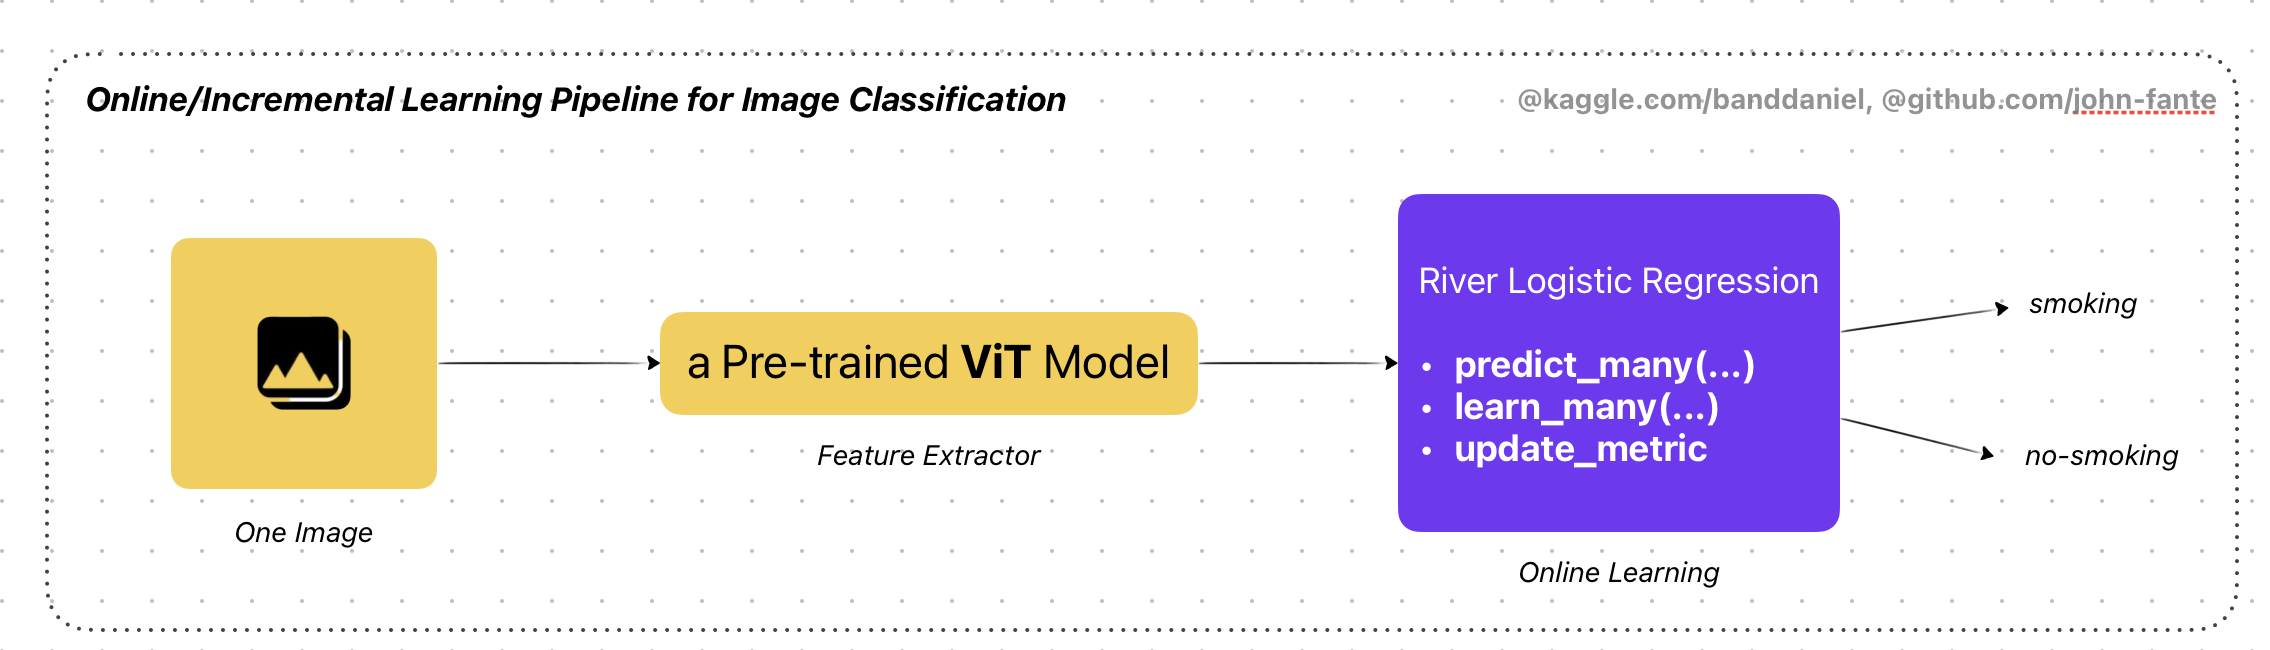


* I used **River** library for online/incremental learning[2], 
* I used a mirrored strategy (using 2 T4 GPU at the same time),
* I used a customized ViT model [3],
* Used <b>tf.data</b> for input pipeline,
* I used a Linear Regression model for classification (from River),

In [1]:
# Importing dependencies

import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import re
import itertools

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.models import Model

IMG_SIZE = 224, 224
BATCH_SIZE = 32
SEED = 19
AUTO = tf.data.AUTOTUNE

In [2]:
from IPython.display import clear_output

!pip install river==0.19.0
!pip install vit_keras
!pip install scipy==1.11.2

clear_output()

In [3]:
from vit_keras import vit

from river import compose, optim, metrics, preprocessing
from river.stream import iter_pandas
from river.linear_model import LogisticRegression

In [4]:
# Creatin mirrored strategy and the model

stg = tf.distribute.MirroredStrategy()

# <span style="color:#e74c3c;"> Reading </span> Data

In [5]:
# Creating main dataframe contains image paths and their classes.

def create_images_list(path):
    full_path = []
    images = sorted(os.listdir(path))
    for i in images:
        full_path.append(os.path.join(path, i))
        
    return full_path, images


train_images = create_images_list('/kaggle/input/smoking/Training/Training')
valid_imaged = create_images_list('/kaggle/input/smoking/Validation/Validation')
test_images = create_images_list('/kaggle/input/smoking/Testing/Testing')

# look-up table
classes = {0:'not_smoking', 1 : 'smoking'}


train_data = pd.DataFrame({'img': train_images[0], 'label': np.NaN, 'image_name': train_images[1]})
valid_data = pd.DataFrame({'img': valid_imaged[0], 'label': np.NaN, 'image_name': valid_imaged[1]})
test_data = pd.DataFrame({'img': test_images[0], 'label': np.NaN, 'image_name': test_images[1]})


def create_class(X):
    reg = re.split("_", X)
    if reg[0] == 'notsmoking':
        return 0
    elif reg[0] == 'smoking':
        return 1
    else:
        print('wrong class ...')

train_data['label'] = train_data['image_name'].apply(create_class)
valid_data['label'] = valid_data['image_name'].apply(create_class)
test_data['label'] = test_data['image_name'].apply(create_class)


train_data = shuffle(train_data, random_state = SEED).reset_index(drop = True)
valid_data = shuffle(valid_data, random_state = SEED).reset_index(drop = True)
test_data = shuffle(test_data, random_state = SEED).reset_index(drop = True)


print("train images -> ", train_data.shape[0])
print("valid images -> ", valid_data.shape[0])
print("test images -> ", test_data.shape[0])

train_data.head()

train images ->  716
valid images ->  180
test images ->  224


,img,label,image_name
0,/kaggle/input/smoking/Training/Training/smokin...,1,smoking_0141.jpg
1,/kaggle/input/smoking/Training/Training/smokin...,1,smoking_0227.jpg
2,/kaggle/input/smoking/Training/Training/smokin...,1,smoking_0410.jpg
3,/kaggle/input/smoking/Training/Training/notsmo...,0,notsmoking_0407.jpg
4,/kaggle/input/smoking/Training/Training/notsmo...,0,notsmoking_0093.jpg


# <span style="color:#e74c3c;"> Creating </span> tf.data Pipeline

In [6]:
# Reading -> Resizing -> Normalization
def img_preprocessing(image, label):
    img = tf.io.read_file(image)
    img = tf.io.decode_jpeg(img, channels = 3)
    img = tf.image.resize(img, size = (IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    
    return img, label


# Data augmentation 
def augmentation(image, label):
    img = tf.image.random_flip_left_right(image, seed = SEED)
    img = tf.image.random_brightness(img, 0.1, seed = SEED)
    img = tf.image.random_contrast(img, 0.2, 0.4, seed = SEED)
    img = tf.image.random_saturation(img, 2, 5, seed = SEED)
    
    return img, label

In [7]:
# Creating dataset loaders and tf.datasets

train_loader = tf.data.Dataset.from_tensor_slices((train_data['img'], train_data['label']))
train_dataset = (train_loader
                 .map(img_preprocessing, num_parallel_calls = AUTO)
                 .map(augmentation, num_parallel_calls = AUTO)
                 .shuffle(BATCH_SIZE * 10)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTO))


# Training dataset without shuffling and data augmantation operations for the classification stage
train_loader_feature = tf.data.Dataset.from_tensor_slices((train_data['img'], train_data['label']))


valid_loader = tf.data.Dataset.from_tensor_slices((valid_data['img'], valid_data['label']))
valid_dataset = (valid_loader
                 .map(img_preprocessing, num_parallel_calls = AUTO)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTO))


test_loader = tf.data.Dataset.from_tensor_slices((test_data['img'], test_data['label']))
test_dataset = (test_loader
                 .map(img_preprocessing, num_parallel_calls = AUTO)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTO))

# <span style="color:#3498db;"> Feature Extraction </span>

# <span style="color:#e74c3c;"> Pretrained ViT Model Feature Extractor </span>


In [8]:
from vit_keras import vit


with stg.scope():
    vit_model = vit.vit_b16(image_size = IMG_SIZE, activation = 'softmax', pretrained = True, include_top = False, pretrained_top = False, classes = 2)

    inp = Input(shape = (*IMG_SIZE, 3))
    vit = vit_model(inp)
    X = Flatten(name = 'the_feature_layer')(vit)
    X = Dense(128, activation = 'gelu')(X)
    X = Dense(16, activation = 'gelu')(X)
    out = Dense(2, activation = 'softmax')(X)

    f_model = Model(inputs = inp, outputs = out)
    
    f_model.compile(optimizer = tf.keras.optimizers.AdamW(learning_rate = 0.0001, weight_decay = 0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = ['acc'] )

347502902/347502902 [==============================] - 1s 0us/step


In [9]:
# Training feature extraction model and saved

hist = f_model.fit(train_dataset, epochs = 4, batch_size = BATCH_SIZE, validation_data = valid_dataset)
f_model.save("vit_feature_extractor.h5")

Epoch 1/4
23/23 [==============================] - 130s 1s/step - loss: 0.4811 - acc: 0.7640 - val_loss: 0.1271 - val_acc: 0.9389
Epoch 2/4
23/23 [==============================] - 19s 812ms/step - loss: 0.1934 - acc: 0.9260 - val_loss: 0.0804 - val_acc: 0.9722
Epoch 3/4
23/23 [==============================] - 19s 823ms/step - loss: 0.1104 - acc: 0.9553 - val_loss: 0.0715 - val_acc: 0.9833
Epoch 4/4
23/23 [==============================] - 19s 829ms/step - loss: 0.0615 - acc: 0.9804 - val_loss: 0.0444 - val_acc: 0.9833


In [10]:
# Validation and Test evaluations of ViT model

with stg.scope():
    print('ViT model results')
    print('--'*50)
    val_eval_vit = f_model.evaluate(valid_dataset)
    print('Validation Loss: {0:.3f}'.format(val_eval_vit[0]))
    print('Validation Accuracy: {0:.3f} %'.format(val_eval_vit[1]*100))
    print('--'*50)
    test_eval_vit = f_model.evaluate(test_dataset)
    print('Test Loss: {0:.3f}'.format(test_eval_vit[0]))
    print('Test Accuracy: {0:.3f} %'.format(test_eval_vit[1]*100))

ViT model results
----------------------------------------------------------------------------------------------------
6/6 [==============================] - 2s 217ms/step - loss: 0.0444 - acc: 0.9833
Validation Loss: 0.044
Validation Accuracy: 98.333 %
----------------------------------------------------------------------------------------------------
7/7 [==============================] - 2s 233ms/step - loss: 0.1186 - acc: 0.9554
Test Loss: 0.119
Test Accuracy: 95.536 %


# <span style="color:#e74c3c;"> Online Classification </span> Stage

In this stage, I tried to implement online/incremental learning for an image classification problem. Our model **learns from only one image of each loop** (like each epoch with the batch size of 1).


In [11]:
# Reading saved model and weights
feature_extr = tf.keras.models.load_model('/kaggle/working/vit_feature_extractor.h5')

# Feature extraction model 
feature_extractor_model = Model(inputs=feature_extr.input,
                                outputs=feature_extr.get_layer('the_feature_layer').output)

# <span style="color:#e74c3c;"> Online Training </span> w/River

In [12]:
# Train dataset with batch_size = 1
# for learning with one image each loop

train_dataset_feature_1_batch = (train_loader_feature.map(img_preprocessing, num_parallel_calls = AUTO).batch(1).prefetch(AUTO))

In [13]:
# Iterator from tf.data pipeline (with batch_size = 1 for learn_one each iteration)
np_iter = train_dataset_feature_1_batch.as_numpy_iterator()

# River model for online/incremental learning
stream_model = preprocessing.StandardScaler()
stream_model |= LogisticRegression(optim.SGD(0.01))

# Classification metrics
metric_acc = metrics.Accuracy()
metric_rocauc = metrics.ROCAUC()
metric_f1 = metrics.F1()

y_preds = []
acc = []
rocauc = []
f1 = []


# Online training loop
count = 0
for x, y in itertools.islice(np_iter, 1, train_data.shape[0], 1):
    y = y[0]
    
    # Creating features using the ViT feature extractor
    with stg.scope():
        vit_features = feature_extractor_model.predict(x, verbose = 0)
    
    new_feature_column_names = []
    for i in range(vit_features.shape[1]):
        new_feature_column_names.append('feature_{0}'.format(i+1))
    
    # Creating dataframe for the one sample features (1,768)
    train_features = pd.DataFrame(vit_features, columns = new_feature_column_names)

    # Training using one image features 
    y_pred = stream_model.predict_many(train_features)
    stream_model.learn_many(train_features, pd.Series(y))
   
    if y_pred.values == True:
        y_pred = 1
    elif y_pred.values == False:
        y_pred = 0
    
    # Updating parameters
    metric_acc.update(y, y_pred)
    acc.append(metric_acc.get()*100)

    metric_rocauc.update(y, y_pred)
    rocauc.append(metric_rocauc.get())
    
    metric_f1.update(y, y_pred)
    f1.append(metric_f1.get())

    print('STEP ({0}), Accuracy: {1:.2f} %, ROCAUC Score: {2:.2f}, F1 Score: {3:.2f}'.format(count + 1, metric_acc.get()*100, metric_rocauc.get(),  metric_f1.get()))
    y_preds.append(y_pred)
    
    count +=1

STEP (1), Accuracy: 0.00 %, ROCAUC Score: -0.00, F1 Score: 0.00
STEP (2), Accuracy: 50.00 %, ROCAUC Score: -0.00, F1 Score: 0.67
STEP (3), Accuracy: 66.67 %, ROCAUC Score: 0.75, F1 Score: 0.67
STEP (4), Accuracy: 75.00 %, ROCAUC Score: 0.75, F1 Score: 0.67
STEP (5), Accuracy: 60.00 %, ROCAUC Score: 0.58, F1 Score: 0.50
STEP (6), Accuracy: 66.67 %, ROCAUC Score: 0.62, F1 Score: 0.50
STEP (7), Accuracy: 71.43 %, ROCAUC Score: 0.71, F1 Score: 0.67
STEP (8), Accuracy: 75.00 %, ROCAUC Score: 0.75, F1 Score: 0.75
STEP (9), Accuracy: 77.78 %, ROCAUC Score: 0.78, F1 Score: 0.80
STEP (10), Accuracy: 80.00 %, ROCAUC Score: 0.80, F1 Score: 0.80
STEP (11), Accuracy: 81.82 %, ROCAUC Score: 0.82, F1 Score: 0.80
STEP (12), Accuracy: 83.33 %, ROCAUC Score: 0.83, F1 Score: 0.83
STEP (13), Accuracy: 84.62 %, ROCAUC Score: 0.85, F1 Score: 0.86
STEP (14), Accuracy: 85.71 %, ROCAUC Score: 0.85, F1 Score: 0.88
STEP (15), Accuracy: 86.67 %, ROCAUC Score: 0.87, F1 Score: 0.88
STEP (16), Accuracy: 87.50 %, ROC

# <span style="color:#e74c3c;"> Online Training </span> Results

In [14]:
def plot_incremental_results(data1, data2, data3):
    fig,axs = plt.subplots(1,3, figsize = (12,4))

    title_0 = 'ROCAUC' + str(' (The last value: {0:.3f})'.format(data1[-1]))
    axs[0].plot(data1)
    axs[0].set_title(title_0)
    axs[0].set_xlabel('samples')
    
    title_1 = 'F1 Score' + str(' (The last value: {0:.3f})'.format(data2[-1]))
    axs[1].plot(data1)
    axs[1].set_title(title_1)
    axs[1].set_xlabel('samples')


    title_2 = 'Accuracy' + str(' (The last value: {0:.3f} %)'.format(data3[-1]))
    axs[2].plot(data3)
    axs[2].set_title(title_2)
    axs[2].set_xlabel('samples')
    
    plt.tight_layout()

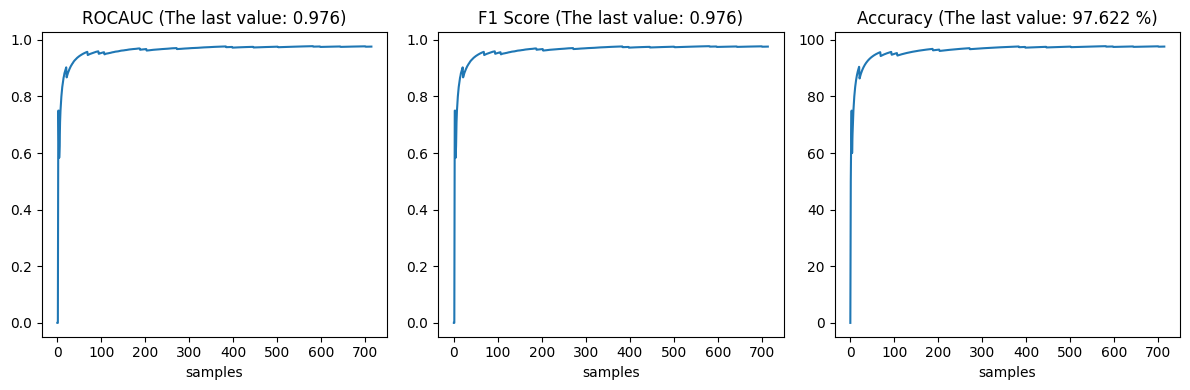

In [15]:
plot_incremental_results(rocauc, f1, acc)

# <span style="color:#e74c3c;"> Test  </span> Set Performance

In [16]:
# Creating test features
with stg.scope():
    test_vit_features = feature_extractor_model.predict(test_dataset, verbose = 0)
    
new_feature_column_names = []
for i in range(test_vit_features.shape[1]):
    new_feature_column_names.append('feature_{0}'.format(i+1))

test_features = pd.DataFrame(test_vit_features, columns = new_feature_column_names)
test_features.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_759,feature_760,feature_761,feature_762,feature_763,feature_764,feature_765,feature_766,feature_767,feature_768
0,-1.124674,-0.448712,0.461819,0.191078,-0.607352,-0.935962,0.062623,1.689320,0.642083,-1.445727,...,-0.699971,0.140223,-0.539996,1.235890,2.058764,0.171976,-0.054471,-1.775972,-0.601819,-0.952278
1,-0.658082,-1.199393,-0.578585,1.245643,0.619282,-0.322634,-1.274407,0.502780,-0.618558,-0.075408,...,-0.963953,0.211151,1.743360,-0.580594,2.075808,-0.279424,0.056685,0.124339,-0.577988,0.072390
2,1.247769,-1.186720,0.652753,-0.296886,-1.609337,0.036727,0.994170,1.072981,-1.216419,-0.712346,...,-0.768362,0.166421,-0.917913,-0.444503,1.399427,0.482999,-1.043728,0.088463,-0.609856,0.643955
3,-0.761084,0.183220,0.455274,0.106096,-0.646257,-0.304568,-0.410244,1.025421,0.069517,-1.132569,...,0.285761,0.157561,-0.417601,-0.361019,1.782441,0.638674,0.852850,-0.845562,-0.883389,0.793818
4,0.544361,-0.188273,-0.382421,0.938180,-0.985962,0.502625,0.593533,-0.099586,-0.120129,-0.796812,...,-0.729965,0.102975,-1.494181,-0.622193,1.185578,-0.353161,-1.239561,-0.056155,-0.620306,1.712292


# <span style="color:#e74c3c;"> Test  </span> Prediction w/River

In [17]:
# Test prediction with the River model

test_pred = stream_model.predict_many(test_features)

In [18]:
# Predictions and scores

mse = mean_squared_error(test_data['label'], test_pred)
f1 = f1_score(test_data['label'], test_pred, average = 'weighted')
acc = accuracy_score(test_data['label'], test_pred)

print('Mean Squared Error : {0:.5f}'.format(mse))
print('Weighted F1 Score : {0:.3f}'.format(f1))
print('Accuracy Score : {0:.3f} %'.format(acc*100))

Mean Squared Error : 0.04464
Weighted F1 Score : 0.955
Accuracy Score : 95.536 %


# <span style="color:#e74c3c;"> Test Classification </span> Report

In [19]:
# classification report

clf_report = classification_report(test_data['label'], test_pred, target_names = list(classes.values()))
print(clf_report)

              precision    recall  f1-score   support

 not_smoking       0.97      0.94      0.95       112
     smoking       0.94      0.97      0.96       112

    accuracy                           0.96       224
   macro avg       0.96      0.96      0.96       224
weighted avg       0.96      0.96      0.96       224



# <span style="color:#e74c3c;"> Test Confusion </span> Matrix

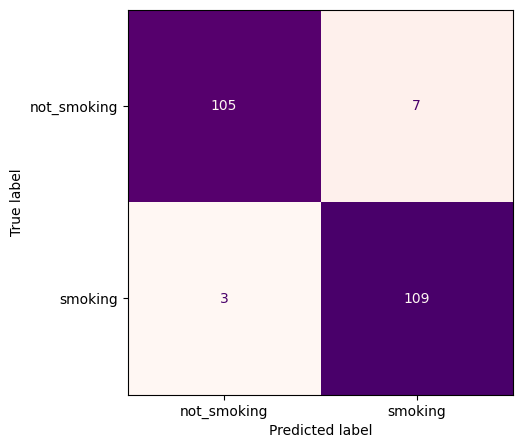

In [20]:
cm = confusion_matrix(test_data['label'], test_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels = list(classes.values())) 

fig, ax = plt.subplots(figsize=(5,5))
cmd.plot(ax=ax, cmap = 'RdPu', colorbar = False)